In [1]:
import os
import sys

sys.path.append(os.path.abspath('..'))
from game import RepeatedReferenceGame, Trial
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
import re

plt.rcParams['figure.dpi'] = 300

In [2]:
from nltk.tokenize import word_tokenize as tokenize
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
from nltk.stem.porter import *
stemmer = PorterStemmer()

In [3]:
def snd(utterance_list):
    if len(utterance_list) == 1:
        return 0

    processed = [[stemmer.stem(w) for w in tokenize(u.lower()) if w not in stop_words and (w.islower() or w.isalnum())] for u in utterance_list]
    utterance_W = []
    for i, utterance in enumerate(processed):
        token_W = []
        for j, token in enumerate(utterance):
            denominator = len(utterance_list) - 1
            num_unseen = 0
            for k, alt_utterance in enumerate(processed):
                if i == k:
                    continue
                k_tokens = set(alt_utterance)
                if token not in k_tokens:
                    num_unseen += 1
            token_W.append(num_unseen / denominator)
        utterance_W.append(np.mean(token_W))
    return np.mean(utterance_W).item()

In [4]:
df_list = list()

In [5]:
gameid2context = dict()
for i, results_file in enumerate(Path("../idefics_lora_expt_configs_results").glob("*.json")):
    expt_name = results_file.name
    speaker = re.search(r"speaker=([^\-\.]+)", expt_name).group(1)
    listener = re.search(r"listener=([^\_\-\.]+)", expt_name).group(1)
    num = re.search(r"_([0-9])", expt_name).group(1) if speaker != "human" else 1

    with results_file.open('r') as f:
        for gameid, game in json.load(f).items():
            rrg = RepeatedReferenceGame.model_validate_json(json.dumps(game))
            gameid2context[gameid] = rrg.context
            block_counter = Counter()
            target_utterances = defaultdict(list)
            prev_block_num_words = defaultdict(int)
            prev_block_correct = defaultdict(bool)
            for trial_idx, trial in enumerate(rrg.trials):
                block_counter[trial.target] += 1
                num_raw_words = len(trial.message.split()) if trial.message else 0
                df_list.append({
                    "condition": i,
                    "speaker": speaker,
                    "listener": listener,
                    "gameid": gameid,
                    "trial_idx": trial_idx,
                    "target": trial.target,
                    "message": trial.message,
                    "block_idx": block_counter[trial.target],
                    "num_raw_words": num_raw_words,
                    "correct": trial.correct,
                    "sample_id": num,
                })

In [6]:
df = pd.DataFrame(df_list)

In [7]:
speakers = df.speaker.unique().tolist()

In [20]:
df.groupby(["speaker", "listener", "gameid", "sample_id", "target"])["message"].agg(lambda x: snd([m for m in x if m])).groupby(["speaker"]).mean()

speaker
human                    0.360055
idefics3                 0.328500
speaker_train_lexgram    0.026461
speaker_train_parts      0.176434
Name: message, dtype: float64

In [23]:
df.groupby(["speaker", "listener", "sample_id", "target"])["message"].agg(lambda x: snd([m for m in x if m])).groupby(["speaker"]).mean()

speaker
human                    0.423681
idefics3                 0.368298
speaker_train_lexgram    0.052832
speaker_train_parts      0.217148
Name: message, dtype: float64

<Axes: xlabel='block_idx', ylabel='num_raw_words'>

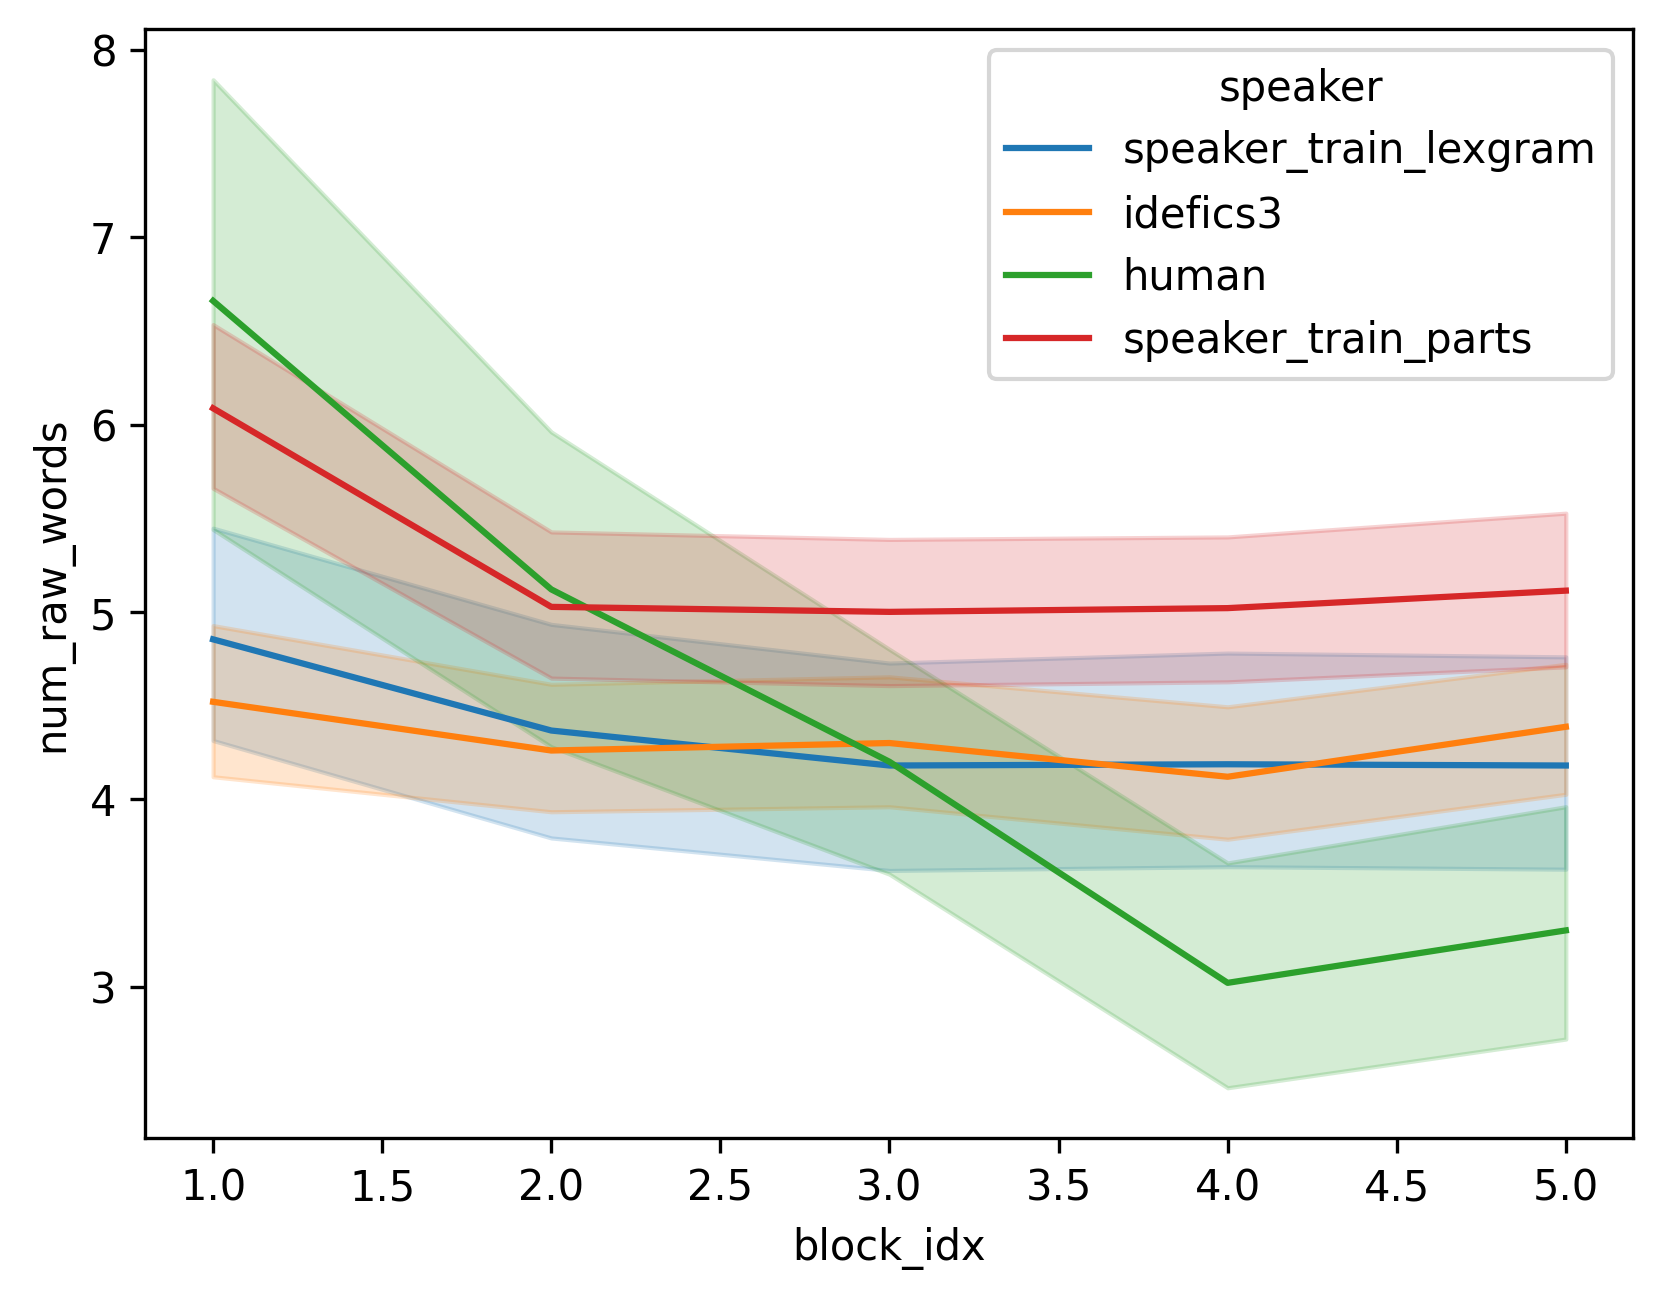

In [22]:
sns.lineplot(data=df, y="num_raw_words", x="block_idx", hue="speaker")

<Axes: xlabel='block_idx', ylabel='correct'>

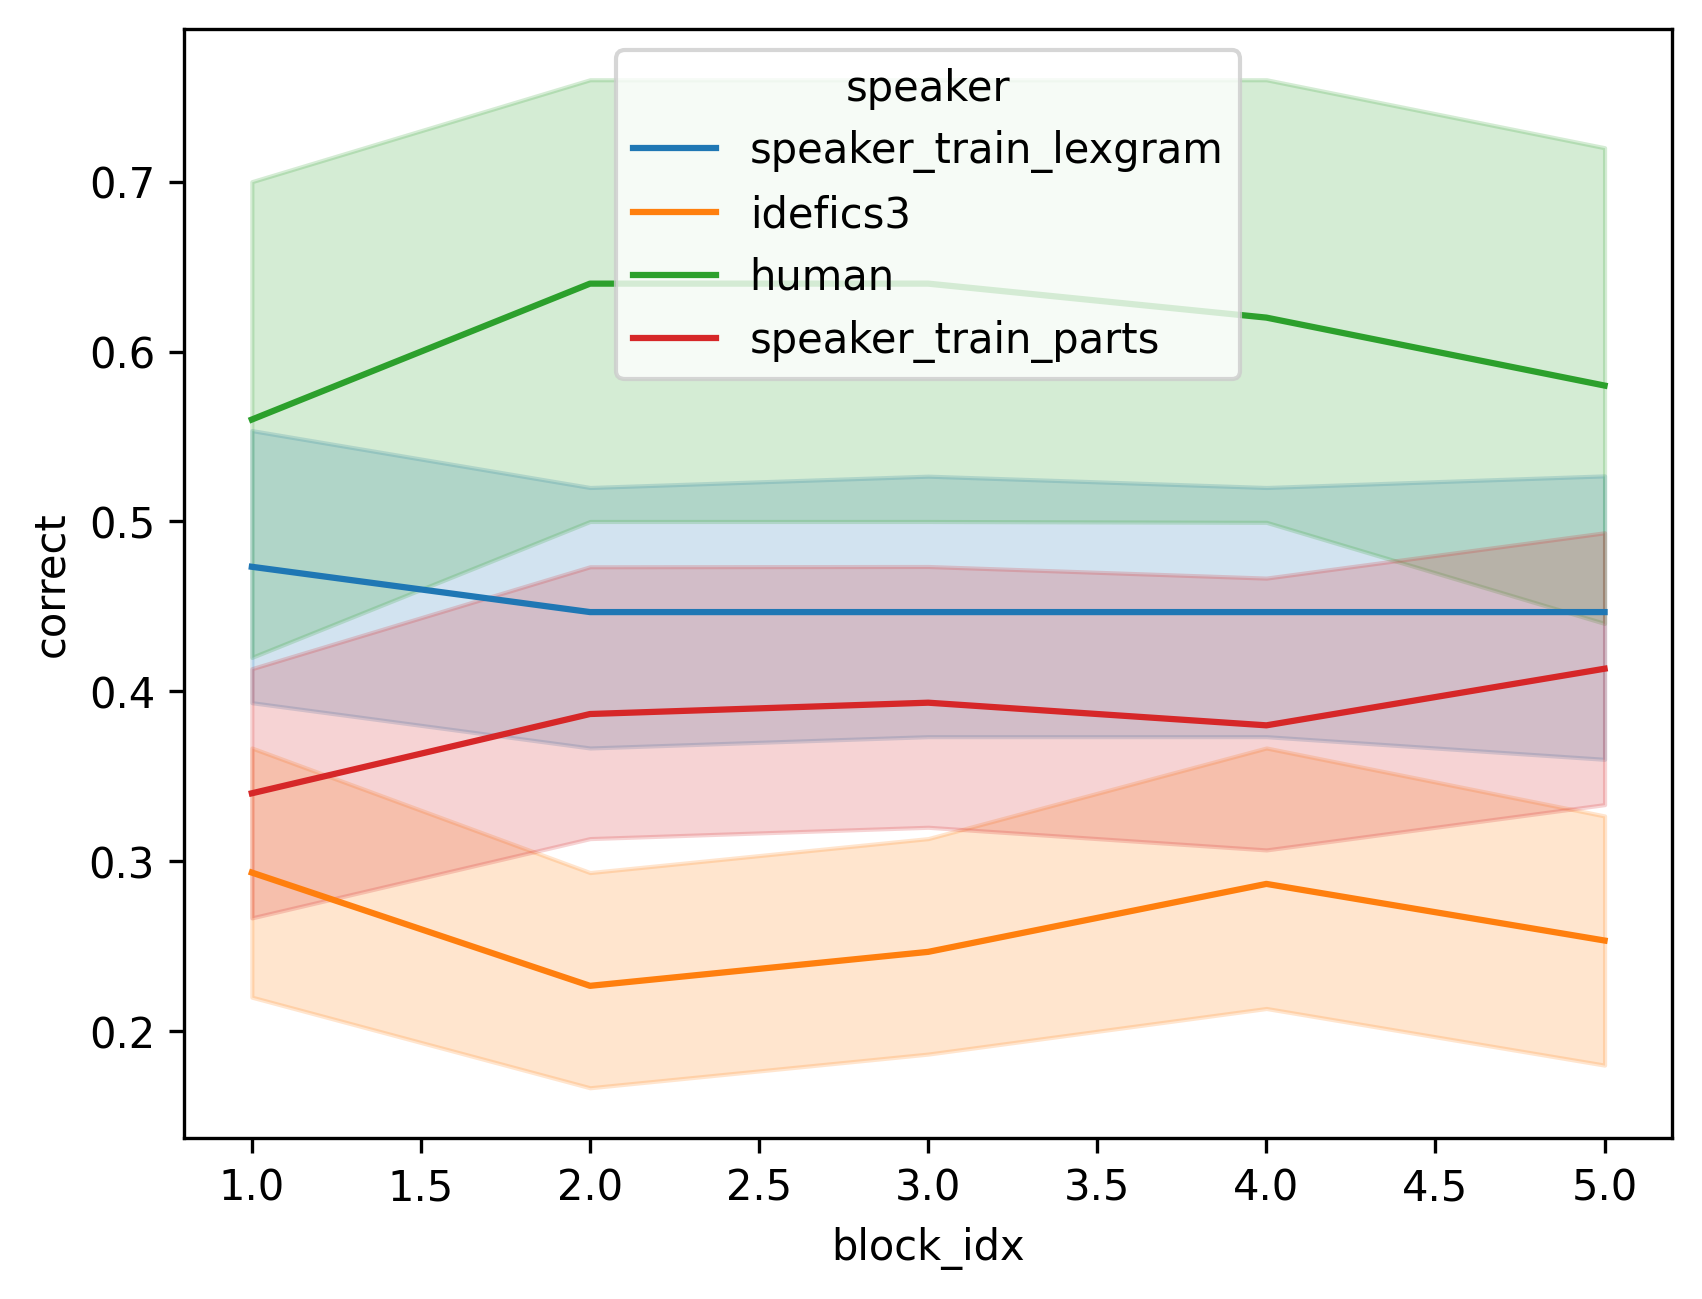

In [25]:
sns.lineplot(data=df, y="correct", x="block_idx", hue="speaker")

In [8]:
grouped_data = dict()
for i, row in df.iterrows():
    if not row.gameid in grouped_data:
        grouped_data[row.gameid] = dict()
    
    if not row.trial_idx in grouped_data[row.gameid]:
        grouped_data[row.gameid][row.trial_idx] = {"target": row.target, "messages": dict()}
    
    if not row.speaker in grouped_data[row.gameid][row.trial_idx]["messages"]:
        grouped_data[row.gameid][row.trial_idx]["messages"][row.speaker] = list()
    
    grouped_data[row.gameid][row.trial_idx]["messages"][row.speaker].append(row.message)

In [9]:
grouped_data["unseen_0"]

{0: {'target': 'page1-172.png',
  'messages': {'speaker_train_lexgram': ['tall building with a square base',
    'A tower',
    'a tower with a square at the bottom'],
   'idefics3': ['Like a tower.', 'A tower made of blocks.', 'Like a tower.'],
   'human': ['Looks like a Llama animal'],
   'speaker_train_parts': ['a person sitting on a chair',
    'a lighthouse with a tower and a foundation',
    'a house with a chimney']}},
 1: {'target': 'page7-202.png',
  'messages': {'speaker_train_lexgram': ['tall triangle with a square on top',
    'A triangle on its side',
    'a triangle with a square on top'],
   'idefics3': ['Like a flower.', 'Looks like a dress.', 'Curved like a bow.'],
   'human': ['small triangle at the base then like a simetric column on top of it'],
   'speaker_train_parts': ['a man holding a briefcase',
    'a person with arms, and a head',
    'a person with a head, and a neck']}},
 2: {'target': 'page3-201.png',
  'messages': {'speaker_train_lexgram': ['a rabbit', 'R

In [15]:
def make_display(key, speakers):
    html_content = """
        <table>
            <!-- Titles Row -->
            <tr>
    """

    # Add titles
    for title in gameid2context[key]:
        html_content += f"            <th>{title[:-4]}</th>\n"

    html_content += "        </tr>\n        <tr>\n"

    # Add images
    for path in gameid2context[key]:
        html_content += f'            <td><img src="./images/{path}"></td>\n'

    html_content += """
            </tr>
        </table>
    """
    html_table = f"""
        <table>
            <tr>
                <th>Target</th>
                {''.join([f'<th>{spk}</th>' for spk in speakers])}
            </tr>
    """

    # Iterate over data to populate rows
    for entry_id in sorted(grouped_data[key].keys()):
        entry = grouped_data[key][entry_id]
        target = entry['target']
        messages = entry['messages']
        html_table += f"""
            <tr>
                <td>{target}</td>"""
            
        for spk in speakers:
            messages_list = messages.get(spk, [None])
            # Add a row for each category and its messages
            if messages_list[0] is None:
                continue
            html_table += f"""
                <td>{'<br>'.join(messages_list)}</td>
            """
        
        html_table += """</tr>
            """

    html_table += "</table>"

    return f"{html_content}\n{html_table}"

In [10]:
html_header = """<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Messages Table</title>
    <style>
        table {
            border-collapse: collapse;
            width: 100%;
        }
        th, td {
            border: 1px solid black;
            padding: 8px;
            text-align: left;
        }
        th {
            background-color: #f2f2f2;
        }
    </style>
</head>
<body>"""

In [16]:
with open("messages_table.html", "w") as f:
    f.write(f"{html_header}\n{make_display("unseen_0", speakers)}\n{make_display("unseen_8", speakers)}\n{make_display("seen_1", speakers)}\n</body>\n</html>")

In [39]:
print(*gameid2context["seen_1"], sep=' ')

page7-41.png page8-169.png page5-86.png page7-125.png page2-20.png


In [37]:
annotated_df = pd.read_json("../saved_annotations.json")

In [38]:
annotated_df["correct"] = annotated_df.apply(lambda x: x['target'] == x['selection_idx'], axis=1)

In [39]:
annotated_df.groupby("speaker")["correct"].mean()

speaker
human                    0.909091
idefics3                 0.303030
speaker_train_lexgram    0.657143
speaker_train_parts      0.466667
Name: correct, dtype: float64

In [41]:
annotated_df.groupby("speaker")["correct"].count()

speaker
human                    11
idefics3                 33
speaker_train_lexgram    35
speaker_train_parts      30
Name: correct, dtype: int64